In [1]:
import tenpy
# from tenpy.models.model import CouplingMPOModel
# from tenpy.networks.site import SpinHalfFermionSite
# from tenpy.networks.mps import MPS
# from tenpy.algorithms import dmrg as tenpy_dmrg
import sys
sys.path.append('..')

# import importlib
# # importlib.reload(sys.modules['src'])
# importlib.reload(sys.modules['utils.bosonization'])
# importlib.reload(sys.modules['utils.slurmhelpers'])

from src.extendedHubbard import HubbardSpinDepV, run_idmrg
from utils.bosonization import ret_Vpm_crit, compute_Luttinger_parameter
from utils.slurmhelpers import ret_arr_for_taskid
import src.observables as observables
import utils.io as io
import logging 
logging.basicConfig(level=logging.INFO)
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import re, glob
import pandas as pd
print(f"TeNPy version: {tenpy.__version__}")
DATA_ROOT = '../../data/iDMRG/'


TeNPy version: 1.1.0


In [2]:
# REQ_DATA = 't_1.00_U_0.10_Vpp_0.800/v2/'
# REQ_DATA = 't_1.00_U_0.10_Vpp_0.800_consNf0_25_chimax_100/'
REQ_DATA = 'v2fwd/t_1.00_U_0.10_Vpp_0.800_consNf0_25_chimax_100/'
PATH_TO_REQ_DATA = os.path.join(DATA_ROOT, REQ_DATA)
file_list = [os.path.join(PATH_TO_REQ_DATA,f) for f in os.listdir(PATH_TO_REQ_DATA) if "chimax_100" in f]
def atomic_action(file): 
    psi, metadata = io.load_mps_with_metadata(file)
    model_params = metadata['model_params']
    row_dict = {
        'psi' : psi, 
        'dV' : model_params['Vpm'] - model_params['Vpp'], 
        'mean_Sz' : metadata['mean_Sz'], 
        'mean_fill' : metadata['mean_fill'],
        'model_params' : model_params,
        'converged' : metadata['converged'], 
        'E' : metadata['E'], 
        'Sz' : metadata['Sz'],
        'Ntot' : metadata["Ntot"], 
    }
    return row_dict
    
df = pd.DataFrame([atomic_action(f) for f in file_list])
df = df.sort_values('dV')
df.head()

,psi,dV,mean_Sz,mean_fill,model_params,converged,E,Sz,Ntot
24,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",3.0,-6.794326e-12,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 3.8, 'Vpp': 0.8, 'bc...",True,-0.563028,"[-6.6102128210630205e-12, -6.978438971786054e-12]","[0.49963472391442565, 0.5003652760855741]"
32,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",3.1,1.432953e-13,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 3.9000000000000004, ...",True,-0.558356,"[1.407519037344588e-13, 1.458386064205203e-13]","[0.500328401829151, 0.4996715981708496]"
29,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",3.2,-1.010983e-12,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 4.0, 'Vpp': 0.8, 'bc...",True,-0.553847,"[-1.0047047118524786e-12, -1.0172611508567046e...","[0.5003049933426775, 0.4996950066573244]"
21,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",3.3,1.059266e-12,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 4.1, 'Vpp': 0.8, 'bc...",True,-0.549509,"[1.0410755267978299e-12, 1.0774567523136146e-12]","[0.5003499826907956, 0.4996500173092071]"
14,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",3.4,-1.158711e-04,0.5,"{'L': 2, 'U': 0.1, 'Vpm': 4.2, 'Vpp': 0.8, 'bc...",True,-0.545357,"[-0.00011594831287374508, -0.00011579390681158...","[0.5001746753981045, 0.4998253246018967]"


(-0.012499999999829375, 0.1)

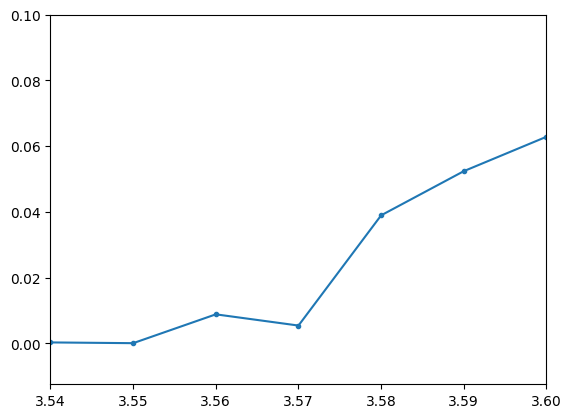

In [11]:
fig, ax = plt.subplots(1)
mask = df['converged']
ax.plot(df.loc[mask, 'dV'], np.abs(df.loc[mask, 'mean_Sz']), ls='-', marker='.', c='C0')
ax.plot(df.loc[~mask, 'dV'], np.abs(df.loc[~mask, 'mean_Sz']), ls='', marker='x', c='r')
ax.set_xlim(3.54,3.6)
ax.set_ylim(None, 0.1)
# ax.plot(df.loc[mask, 'dV'], np.abs(df.loc[mask, 'mean_fill']), ls='-', marker='.', c='C1')
# ax.plot(df.loc[~mask, 'dV'], np.abs(df.loc[~mask, 'mean_fill']), ls='', marker='x', c='r')
# ax.plot(df.loc[mask, 'dV'], np.abs(df.loc[mask, 'E']), ls='-', marker='.', c='C2')
# ax.plot(df.loc[~mask, 'dV'], np.abs(df.loc[~mask, 'E']), ls='', marker='x', c='r')

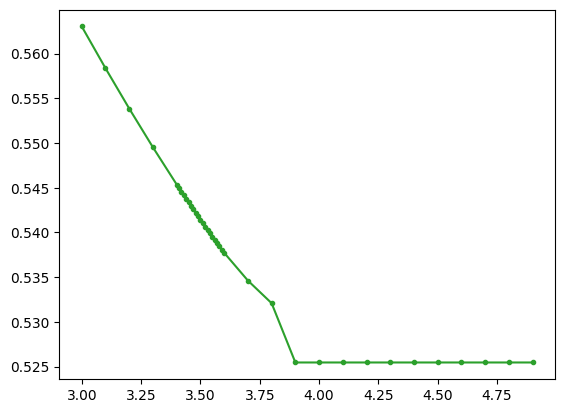

In [8]:
plt.plot(df.loc[mask, 'dV'], np.abs(df.loc[mask, 'E']), ls='-', marker='.', c='C2')
plt.plot(df.loc[~mask, 'dV'], np.abs(df.loc[~mask, 'E']), ls='', marker='x', c='r')
# plt.plot(df.loc[mask, 'dV'], np.abs(df.loc[mask, 'mean_fill']), ls='-', marker='.', c='C1')
# plt.plot(df.loc[~mask, 'dV'], np.abs(df.loc[~mask, 'mean_fill']), ls='', marker='x', c='r')